# Taller r: Árbol de Decisión — Clasificación de Vinos


Se usan `scikit-learn`, `pandas`, `matplotlib` y `openpyxl` para exportar resultados a Excel.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

print('librerías cargadas')

librerías cargadas


## 1) Cargar datos
Cargamos el dataset de vinos disponible en `sklearn.datasets`. Convertimos a `DataFrame` para facilitar el análisis.

In [3]:
data = load_wine()
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2) Análisis exploratorio (EDA)
Mostramos dimensiones, estadísticas y distribución de clases.

In [4]:
print('Dimensiones:', df.shape)
print('\nDistribución de clases:')
print(df['target'].value_counts())

# Estadísticas descriptivas
summary = df.describe().T
summary['missing'] = df.isna().sum()
summary


Dimensiones: (178, 14)

Distribución de clases:
target
1    71
0    59
2    48
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max,missing
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83,0
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80,0
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23,0
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00,0
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00,0
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88,0
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08,0
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66,0
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58,0
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00,0


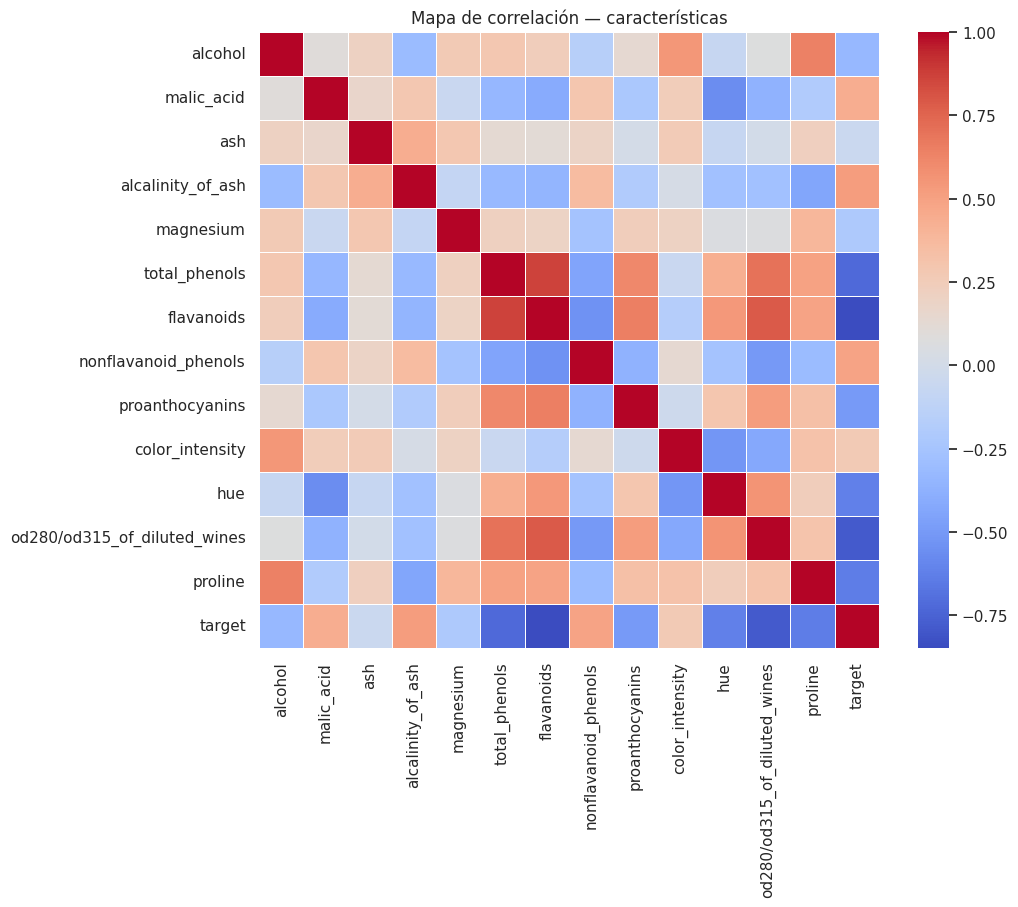

In [5]:
# Gráfica rápida: matriz de correlación y heatmap
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de correlación — características')
plt.show()


## 3) Preprocesamiento
Separamos features y target, normalizamos (opcional) y dividimos en train/test.

In [6]:
X = df.drop(columns=['target'])
y = df['target']

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Train: (133, 13) Test: (45, 13)


## 4) Entrenamiento
Entrenamos un `DecisionTreeClassifier` con búsqueda de hiperparámetros (`GridSearchCV`) para elegir la mejor profundidad y criterio.

In [7]:
params = {'criterion':['gini','entropy'], 'max_depth':[None,2,3,4,5,6,7,8], 'min_samples_split':[2,4,6]}
clf = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5, n_jobs=-1, scoring='accuracy')
clf.fit(X_train, y_train)
print('Mejor score CV:', clf.best_score_)
print('Mejores parámetros:', clf.best_params_)

best = clf.best_estimator_


Mejor score CV: 0.9028490028490029
Mejores parámetros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [8]:
y_pred = best.predict(X_test)
print('Accuracy test:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred))
print('\nMatriz de confusión:\n', confusion_matrix(y_test, y_pred))


Accuracy test: 0.9555555555555556

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.90      1.00      0.95        18
           2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45


Matriz de confusión:
 [[14  1  0]
 [ 0 18  0]
 [ 0  1 11]]


In [11]:
# Guardar reporte de clasificación y matriz de confusión en un Excel
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).T
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=[f'true_{i}' for i in range(cm.shape[0])], columns=[f'pred_{i}' for i in range(cm.shape[1])])

with pd.ExcelWriter('/content/resultados_arbol_vinos.xlsx') as writer:
    report_df.to_excel(writer, sheet_name='classification_report')
    cm_df.to_excel(writer, sheet_name='confusion_matrix')

print('Resultados guardados en /content/resultados_arbol_vinos.xlsx')

Resultados guardados en /content/resultados_arbol_vinos.xlsx


## 5) Visualización del árbol
Mostramos la estructura textual y la gráfica del árbol final.

|--- color_intensity <= 3.82
|   |--- ash <= 3.00
|   |   |--- od280/od315_of_diluted_wines <= 3.73
|   |   |   |--- class: 1
|   |   |--- od280/od315_of_diluted_wines >  3.73
|   |   |   |--- class: 0
|   |--- ash >  3.00
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.58
|   |   |--- alcalinity_of_ash <= 17.65
|   |   |   |--- class: 1
|   |   |--- alcalinity_of_ash >  17.65
|   |   |   |--- class: 2
|   |--- flavanoids >  1.58
|   |   |--- proline <= 724.50
|   |   |   |--- class: 1
|   |   |--- proline >  724.50
|   |   |   |--- class: 0



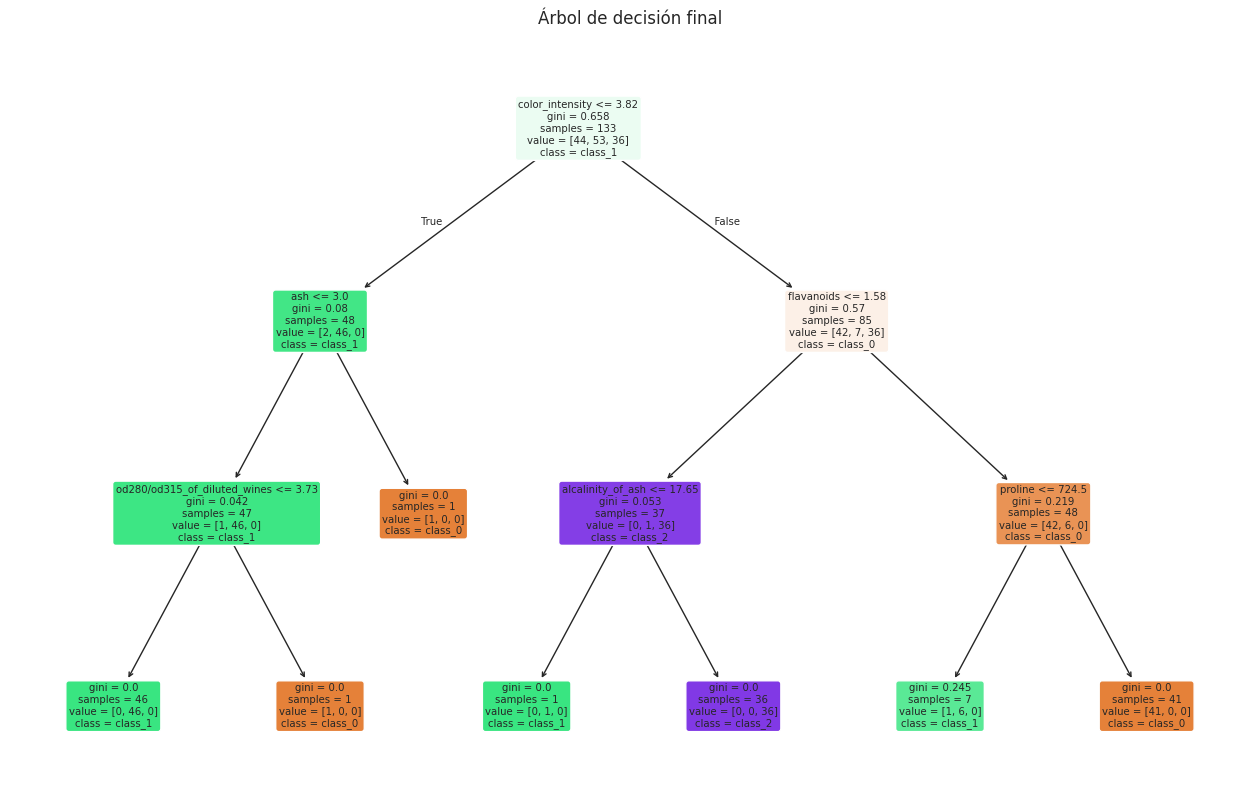

In [12]:
# Mostrar árbol en texto
arbol_text = export_text(best, feature_names=list(X.columns))
print(arbol_text[:1000])

# Plot
plt.figure(figsize=(16,10))
plot_tree(best, feature_names=X.columns, class_names=[str(c) for c in data.target_names], filled=True, rounded=True)
plt.title('Árbol de decisión final')
plt.show()


## 6) Conclusiones
- Se ha entrenado un árbol de decisión con búsqueda de hiperparámetros.
- Se guardaron el reporte y la matriz de confusión en un archivo Excel.
- Observaciones finales y posibles mejoras: poda, validación adicional, uso de RandomForest para comparar.

In [13]:
print('Archivos generados:')
print('- Notebook: /mnt/data/Taller_Arbol_Decision_Vinos_resuelto.ipynb')
print('- Resultados (Excel): /mnt/data/resultados_arbol_vinos.xlsx')


Archivos generados:
- Notebook: /mnt/data/Taller_Arbol_Decision_Vinos_resuelto.ipynb
- Resultados (Excel): /mnt/data/resultados_arbol_vinos.xlsx
